# Dataset Split

-->To avoid overfitting

-->The dataset has been shuffeled and performed random split 

-->19,000 rows for training, 3000 for validation, 3000 for testing 


In [17]:
import pandas as pd

# 1. Load the original raw dataset
file_name = "cold_chain_excursion_data.csv"
df_raw = pd.read_csv(file_name)

# 2. Shuffle the entire dataset randomly to ensure uniform feature distribution
# random_state=42 guarantees reproducibility across runs
df_shuffled = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Partition the shuffled records into independent data segments
df_train = df_shuffled.iloc[0:19000].copy()
df_val   = df_shuffled.iloc[19000:22000].copy()
df_test  = df_shuffled.iloc[22000:25000].copy()

# 4. Physically write out the datasets as independent CSV database tables
df_train.to_csv("cold_chain_train.csv", index=False)
df_val.to_csv("cold_chain_val.csv", index=False)
df_test.to_csv("cold_chain_test.csv", index=False)

print("✅ Data physical partition complete.")
print(f"• Training Set Matrix Saved:   {df_train.shape[0]} rows")
print(f"• Validation Set Matrix Saved: {df_val.shape[0]} rows")
print(f"• Testing Set Matrix Saved:    {df_test.shape[0]} rows")

✅ Data physical partition complete.
• Training Set Matrix Saved:   19000 rows
• Validation Set Matrix Saved: 3000 rows
• Testing Set Matrix Saved:    3000 rows


**Importing necessary libraries**

In [18]:
# ==============================================================================
# ROADMAP STEP 1.1: IMPORT LIBRARIES
# ==============================================================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model Evaluation and Splitting utilities
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Preprocessing and Pipeline components
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Algorithmic Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

print("Core libraries and algorithm modules imported successfully.")

Core libraries and algorithm modules imported successfully.


In [19]:
# ==============================================================================
# ROADMAP STEP 1.2: DATA SET LOAD
# ==============================================================================

# Define the physical data file paths
train_path = "cold_chain_train.csv"
val_path = "cold_chain_val.csv"
test_path = "cold_chain_test.csv"


#! Noise Injection: To simulate real-world data imperfections, we can create "noisy" versions of the datasets by adding random noise to the features. This is optional and can be toggled on/off as needed.

#noisy data
# train_path = "cold_chain_train_noisy.csv"
# val_path = "cold_chain_val_noisy.csv"
# test_path = "cold_chain_test_noisy.csv"


# Load files into independent memory frames
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

# Separate the independent features (X) from the target score (y) for each file
X_train = df_train.drop(columns=['excursion_risk_score'])
y_train = df_train['excursion_risk_score']

X_val = df_val.drop(columns=['excursion_risk_score'])
y_val = df_val['excursion_risk_score']

X_test = df_test.drop(columns=['excursion_risk_score'])
y_test = df_test['excursion_risk_score']

print("Dataset Loading Complete.")
print(f"Training Features:   {X_train.shape} | Training Targets:   {y_train.shape}")
print(f"Validation Features: {X_val.shape}  | Validation Targets: {y_val.shape}")
print(f"Testing Features:    {X_test.shape}  | Testing Targets:    {y_test.shape}")

Dataset Loading Complete.
Training Features:   (19000, 14) | Training Targets:   (19000,)
Validation Features: (3000, 14)  | Validation Targets: (3000,)
Testing Features:    (3000, 14)  | Testing Targets:    (3000,)


**Exploratory Data Analysys**

In [20]:
# ==============================================================================
# ROADMAP STEP 2.1: DESCRIPTIVE STATISTICS AUDIT
# ==============================================================================

print("=== Training Dataset Overview ===")
print(df_train.info())

print("\n=== Numerical Features Distribution Summary ===")
print(df_train.describe().T)

print("\n=== Categorical Features Distribution Summary ===")
print("SHC Code Value Counts:")
print(df_train['SHC_code'].value_counts())

print("\nWeather Condition Value Counts:")
print(df_train['weather_condition'].value_counts())

print("\nMissing Values Count:")
print(df_train.isnull().sum())

=== Training Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19000 entries, 0 to 18999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   timestamp                         19000 non-null  object 
 1   SHC_code                          19000 non-null  object 
 2   target_temp_min                   19000 non-null  float64
 3   target_temp_max                   19000 non-null  float64
 4   current_internal_temp             19000 non-null  float64
 5   door_open_count_1h                19000 non-null  int64  
 6   cumulative_door_open_duration_1h  19000 non-null  int64  
 7   ambient_dry_bulb_temp             19000 non-null  float64
 8   external_relative_humidity        19000 non-null  float64
 9   weather_condition                 19000 non-null  object 
 10  equipment_age_years               19000 non-null  float64
 11  compressor_duty_cycle_ratio_2h   

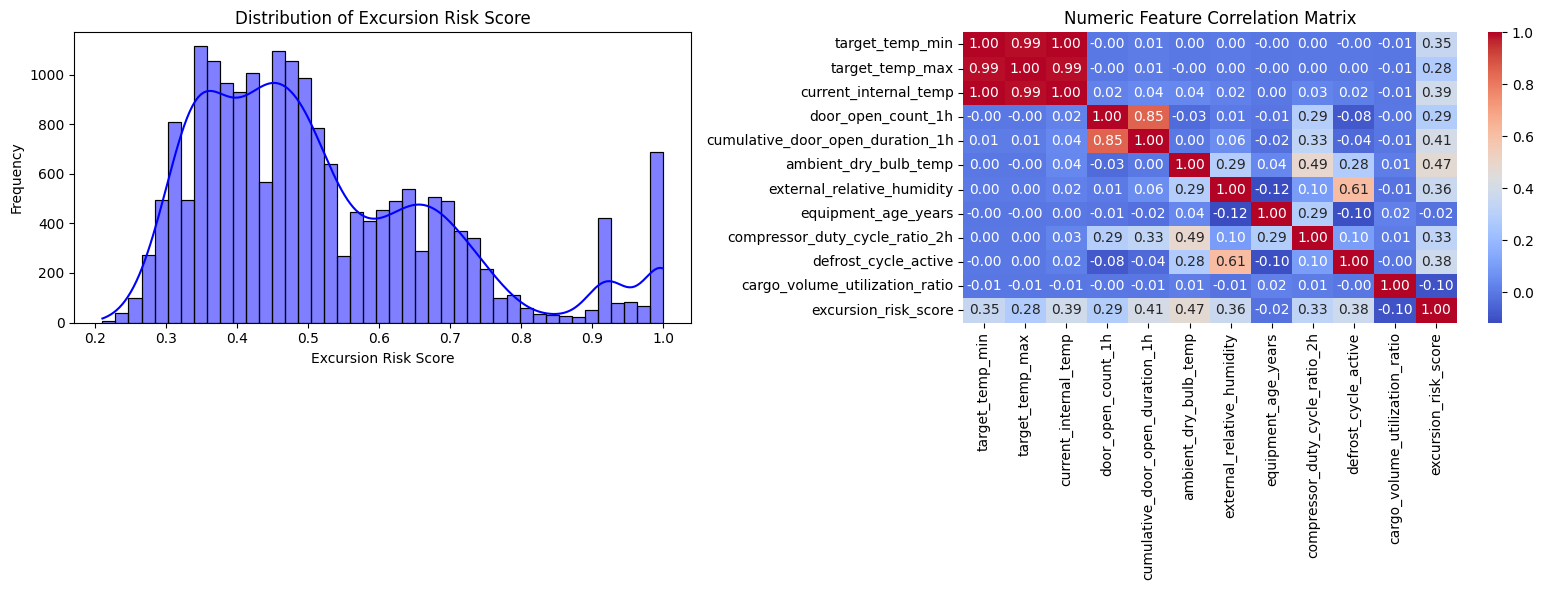

EDA distribution plots generated and saved successfully to 'cold_chain_eda_distributions.png'.


In [21]:
# ==============================================================================
# ROADMAP STEP 2.2: TARGET DISTRIBUTION AND CORRELATION ANALYSIS
# ==============================================================================

# Set up a grid with two independent axes objects without using plt.figure()
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot target distribution
sns.histplot(data=df_train, x='excursion_risk_score', kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribution of Excursion Risk Score')
ax[0].set_xlabel('Excursion Risk Score')
ax[0].set_ylabel('Frequency')

# Plot correlation matrix for numeric features
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
corr_matrix = df_train[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax[1], cbar=True)
ax[1].set_title('Numeric Feature Correlation Matrix')

plt.tight_layout()

# Save the visualization directly to disk
output_plot_path = 'cold_chain_eda_distributions.png'
plt.show()
plt.close()

print(f"EDA distribution plots generated and saved successfully to '{output_plot_path}'.")

In [22]:
import warnings
warnings.filterwarnings('ignore')

SHC_code
COL    0.617771
CRT    0.470357
FRO    0.368189
PIL    0.620703
Name: excursion_risk_score, dtype: float64

=== Target Group Means by Environmental Context (weather_condition) ===
weather_condition
Clear        0.503707
Cloudy       0.485220
Rainy        0.784196
Sandstorm    0.458640
Name: excursion_risk_score, dtype: float64


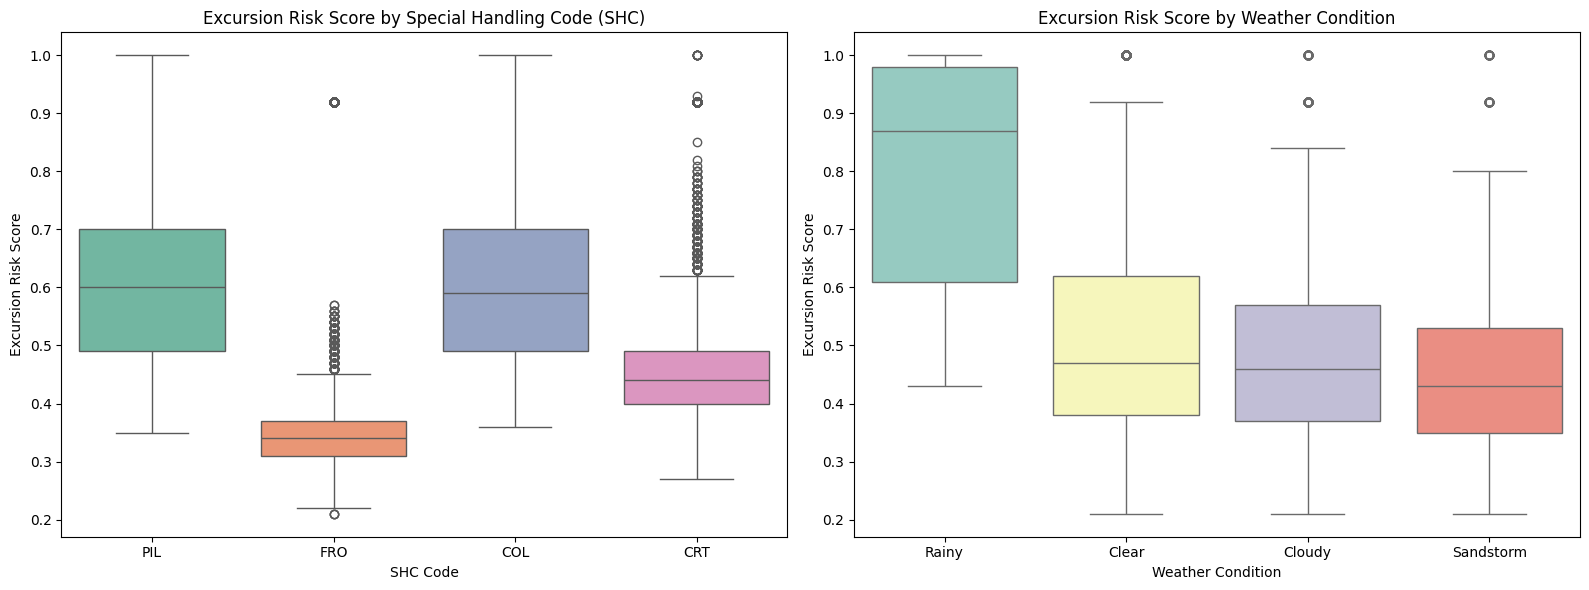


Categorical relationship distribution plots saved to 'cold_chain_eda_categorical_analysis.png'.


In [23]:
shc_group_means = df_train.groupby('SHC_code')['excursion_risk_score'].mean()
print(shc_group_means)

print("\n=== Target Group Means by Environmental Context (weather_condition) ===")
# Compute the exact mathematical mean risk score across unique weather states
weather_group_means = df_train.groupby('weather_condition')['excursion_risk_score'].mean()
print(weather_group_means)

# Generate boxplots to visualize target distribution variance across categorical groups
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot for Special Handling Codes
sns.boxplot(data=df_train, x='SHC_code', y='excursion_risk_score', ax=ax[0], palette='Set2')
ax[0].set_title('Excursion Risk Score by Special Handling Code (SHC)')
ax[0].set_xlabel('SHC Code')
ax[0].set_ylabel('Excursion Risk Score')

# Boxplot for Weather Conditions
sns.boxplot(data=df_train, x='weather_condition', y='excursion_risk_score', ax=ax[1], palette='Set3')
ax[1].set_title('Excursion Risk Score by Weather Condition')
ax[1].set_xlabel('Weather Condition')
ax[1].set_ylabel('Excursion Risk Score')

plt.tight_layout()

# Save categorical boxplot asset to disk
categorical_plot_path = 'cold_chain_eda_categorical_analysis.png'
plt.savefig(categorical_plot_path, dpi=300)
plt.show()
plt.close()

print(f"\nCategorical relationship distribution plots saved to '{categorical_plot_path}'.")

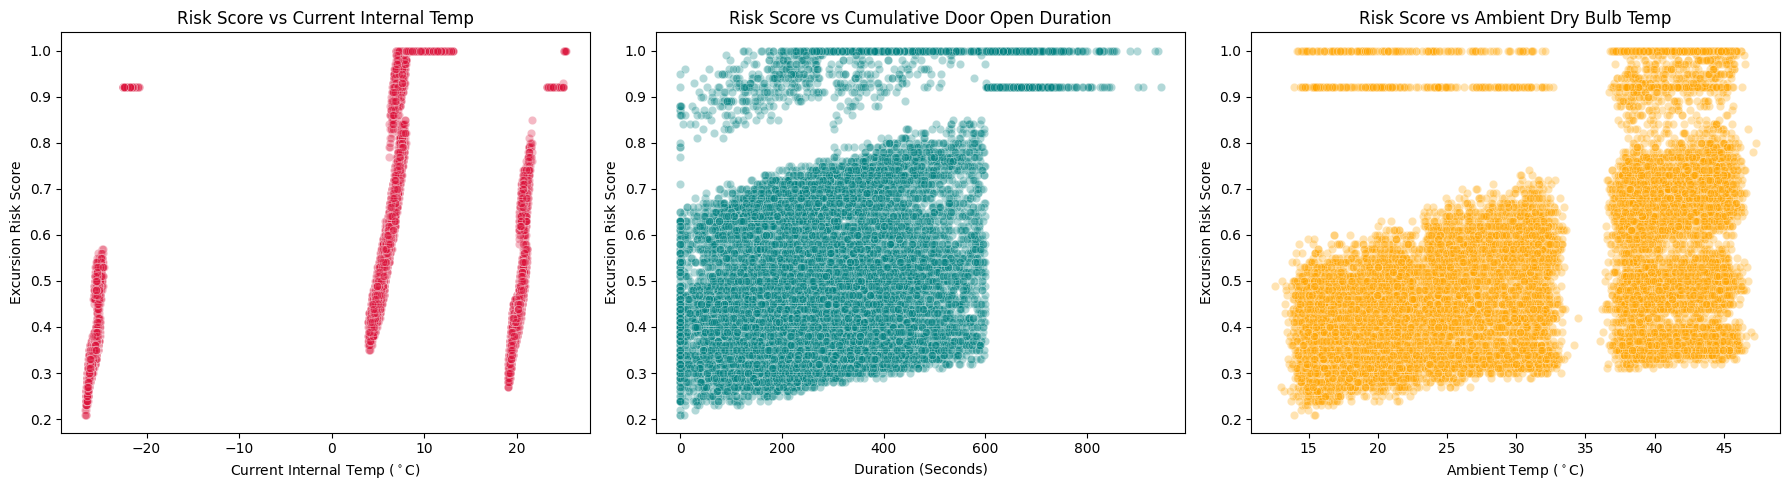

Bivariate scatter interaction plots saved successfully to 'cold_chain_eda_bivariate_analysis.png'.

=== EDA Diagnostic Insights Summary ===
1. Product Base Risks: Chilled (COL) and Pharma (PIL) maintain the highest mean baseline risk metrics (~0.62).
2. Extreme Operational Drivers: Rainy weather environments show a severe impact, spiking the mean risk score to 0.78.


In [24]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Scatter interaction 1: Current Internal Temperature vs Risk Score
sns.scatterplot(data=df_train, x='current_internal_temp', y='excursion_risk_score', ax=ax[0], alpha=0.3, color='crimson')
ax[0].set_title('Risk Score vs Current Internal Temp')
ax[0].set_xlabel('Current Internal Temp ($^\circ$C)')
ax[0].set_ylabel('Excursion Risk Score')

# Scatter interaction 2: Cumulative Door Open Duration vs Risk Score
sns.scatterplot(data=df_train, x='cumulative_door_open_duration_1h', y='excursion_risk_score', ax=ax[1], alpha=0.3, color='teal')
ax[1].set_title('Risk Score vs Cumulative Door Open Duration')
ax[1].set_xlabel('Duration (Seconds)')
ax[1].set_ylabel('Excursion Risk Score')

# Scatter interaction 3: Ambient Dry Bulb Temperature vs Risk Score
sns.scatterplot(data=df_train, x='ambient_dry_bulb_temp', y='excursion_risk_score', ax=ax[2], alpha=0.3, color='orange')
ax[2].set_title('Risk Score vs Ambient Dry Bulb Temp')
ax[2].set_xlabel('Ambient Temp ($^\circ$C)')
ax[2].set_ylabel('Excursion Risk Score')

plt.tight_layout()

# Save bivariate scatter plot asset to disk
bivariate_plot_path = 'cold_chain_eda_bivariate_analysis.png'
plt.savefig(bivariate_plot_path, dpi=300)
plt.show()
plt.close()

print(f"Bivariate scatter interaction plots saved successfully to '{bivariate_plot_path}'.")
print("\n=== EDA Diagnostic Insights Summary ===")
print("1. Product Base Risks: Chilled (COL) and Pharma (PIL) maintain the highest mean baseline risk metrics (~0.62).")
print("2. Extreme Operational Drivers: Rainy weather environments show a severe impact, spiking the mean risk score to 0.78.")

# Data cleaning, preprocessing and feature engineering

In [25]:
# ==============================================================================
# ROADMAP STEP 3.1: ADAPTIVE PREPROCESSOR WITH TYPE-INFERENCE
# ==============================================================================
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder

class AdaptiveProductionPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, date_format='%d:%m:%Y, %H:%M'):
        self.date_format = date_format
        # Metadata storage containers instantiated automatically during fit
        self.datetime_cols_ = []
        self.numeric_cols_ = []
        self.categorical_cols_ = []
        
        # Core mathematical transformation models
        self.scaler_ = StandardScaler()
        self.encoder_ = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        
        # 1. Automatically scan for and isolate datetime columns
        for col in X_df.columns:
            if 'time' in col.lower() or 'date' in col.lower():
                try:
                    pd.to_datetime(X_df[col], format=self.date_format)
                    self.datetime_cols_.append(col)
                except Exception:
                    pass
        
        # Isolate remaining columns that are not time logs
        remaining_cols = [c for c in X_df.columns if c not in self.datetime_cols_]
        
        # 2. Automatically classify features based on runtime data types
        self.numeric_cols_ = X_df[remaining_cols].select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols_ = X_df[remaining_cols].select_dtypes(include=['object', 'category']).columns.tolist()
        
        # 3. Fit the internal mathematical components based on discovered columns
        if self.numeric_cols_:
            self.scaler_.fit(X_df[self.numeric_cols_])
        if self.categorical_cols_:
            self.encoder_.fit(X_df[self.categorical_cols_])
            
        return self
        
    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        output_parts = []
        
        # 1. Scale all discovered continuous numerical attributes
        if self.numeric_cols_:
            num_scaled = self.scaler_.transform(X_df[self.numeric_cols_])
            output_parts.append(num_scaled)
            
        # 2. Encode all discovered discrete nominal text blocks
        if self.categorical_cols_:
            cat_encoded = self.encoder_.transform(X_df[self.categorical_cols_])
            output_parts.append(cat_encoded)
            
        # 3. Parse and unpack cyclical temporal signatures using sine and cosine math
        for col in self.datetime_cols_:
            dt_series = pd.to_datetime(X_df[col], format=self.date_format)
            h_sin = np.sin(2 * np.pi * dt_series.dt.hour / 24.0).values.reshape(-1, 1)
            h_cos = np.cos(2 * np.pi * dt_series.dt.hour / 24.0).values.reshape(-1, 1)
            m_sin = np.sin(2 * np.pi * dt_series.dt.month / 12.0).values.reshape(-1, 1)
            m_cos = np.cos(2 * np.pi * dt_series.dt.month / 12.0).values.reshape(-1, 1)
            output_parts.extend([h_sin, h_cos, m_sin, m_cos])
            
        # Horizontally stack all processed numerical arrays into a single database matrix
        X_out = np.hstack(output_parts)
        return X_out

# Instantiate the newly built dynamic engine
adaptive_preprocessor = AdaptiveProductionPreprocessor()
print("Adaptive type-inference preprocessing engine compiled successfully.")

Adaptive type-inference preprocessing engine compiled successfully.


**Data Preprocessing**

In [26]:
# ==============================================================================
# ROADMAP STEP 3.2: DYNAMIC TRANSFORMATION EXECUTION
# ==============================================================================

print("Running dynamic runtime feature engineering...")

# Fit the dynamic preprocessor exclusively on the training set and transform it
X_train_processed = adaptive_preprocessor.fit_transform(X_train)

# Project the identical pre-calculated weights onto validation and testing splits
X_val_processed = adaptive_preprocessor.transform(X_val)
X_test_processed = adaptive_preprocessor.transform(X_test)

print("\n=== Production Metadata Analysis ===")
print(f"• Datetime Fields Discovered:  {adaptive_preprocessor.datetime_cols_}")
print(f"• Numerical Fields Discovered: {len(adaptive_preprocessor.numeric_cols_)} columns found")
print(f"• Categorical Fields Discovered:{len(adaptive_preprocessor.categorical_cols_)} columns found")

print("\n=== Output Processed Arrays Overview ===")
print(f"• X_train_processed shape: {X_train_processed.shape}")
print(f"• X_val_processed shape:   {X_val_processed.shape}")
print(f"• X_test_processed shape:  {X_test_processed.shape}")
print("Dynamic preprocessing complete. Pipeline is resilient against future column additions.")

Running dynamic runtime feature engineering...

=== Production Metadata Analysis ===
• Datetime Fields Discovered:  ['timestamp']
• Numerical Fields Discovered: 11 columns found
• Categorical Fields Discovered:2 columns found

=== Output Processed Arrays Overview ===
• X_train_processed shape: (19000, 23)
• X_val_processed shape:   (3000, 23)
• X_test_processed shape:  (3000, 23)
Dynamic preprocessing complete. Pipeline is resilient against future column additions.


In [27]:
# ==============================================================================
# ROADMAP STEP 4.1: NORMAL MODEL TRAINING AND REVENUE BENCHMARKING
# ==============================================================================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Define candidate models with explicit baseline parameters
candidate_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(max_depth=6, n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(max_depth=4, learning_rate=0.05, n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(depth=4, learning_rate=0.05, iterations=100, random_state=42, verbose=0)
}

normal_comparison_records = []

print("Starting standard training and validation evaluation...")

for name, model in candidate_models.items():
    print(f"Training {name} normally on the 19,000 row training dataset...")
    
    # Train the model once
    model.fit(X_train_processed, y_train)
    
    # Generate predictions on the training set
    train_preds = model.predict(X_train_processed)
    # Generate predictions on the completely separate validation set
    val_preds = model.predict(X_val_processed)
    
    # Calculate Training Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_mae = mean_absolute_error(y_train, train_preds)
    train_r2 = r2_score(y_train, train_preds)
    
    # Calculate Validation Metrics
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_mae = mean_absolute_error(y_val, val_preds)
    val_r2 = r2_score(y_val, val_preds)
    
    normal_comparison_records.append({
        "Model": name,
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "Train MAE": train_mae,
        "Val MAE": val_mae,
        "Train R2": train_r2,
        "Val R2": val_r2
    })

# Convert records to a summary dataframe
df_normal_comparison = pd.DataFrame(normal_comparison_records)
print("\n=== Normal Training Evaluation Complete ===")
print(df_normal_comparison.to_markdown(index=False))

Starting standard training and validation evaluation...
Training Linear Regression normally on the 19,000 row training dataset...
Training Random Forest normally on the 19,000 row training dataset...
Training XGBoost normally on the 19,000 row training dataset...
Training CatBoost normally on the 19,000 row training dataset...

=== Normal Training Evaluation Complete ===
| Model             |   Train RMSE |   Val RMSE |   Train MAE |    Val MAE |   Train R2 |   Val R2 |
|:------------------|-------------:|-----------:|------------:|-----------:|-----------:|---------:|
| Linear Regression |    0.0388707 |  0.0369329 |  0.0185209  | 0.0184141  |   0.953239 | 0.958672 |
| Random Forest     |    0.0235477 |  0.0238583 |  0.0175311  | 0.0174547  |   0.982839 | 0.982754 |
| XGBoost           |    0.011541  |  0.011712  |  0.00791912 | 0.00822805 |   0.995878 | 0.995844 |
| CatBoost          |    0.0181419 |  0.0182267 |  0.0126669  | 0.012431   |   0.989814 | 0.989935 |


In [28]:
# ==============================================================================
# ROADMAP STEP 4.2: OVERFITTING VISUALIZATION (TRAIN VS VALIDATION GAP)
# ==============================================================================

# Reformat data slightly into a long format for easier comparative plotting
df_melted = df_normal_comparison.melt(
    id_vars=["Model"], 
    value_vars=["Train R2", "Val R2"], 
    var_name="Dataset Slicing", 
    value_name="R2 Score"
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_melted, 
    x="Model", 
    y="R2 Score", 
    hue="Dataset Slicing", 
    ax=ax, 
    palette="Set2"
)

ax.set_title("Generalization Assessment: Training R-Squared vs. Validation R-Squared")
ax.set_xlabel("Algorithmic Model")
ax.set_ylabel("R-Squared ($R^2$) Metric Score")
ax.set_ylim(0.0, 1.1)

# Annotate values on top of the comparative bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()

# Save overfitting assessment plot to disk
overfitting_chart_path = 'cold_chain_overfitting_analysis.png'
plt.savefig(overfitting_chart_path, dpi=300)
plt.close()

print(f"Overfitting assessment chart saved successfully to '{overfitting_chart_path}'.")

Overfitting assessment chart saved successfully to 'cold_chain_overfitting_analysis.png'.


In [29]:
# ==============================================================================
# ROADMAP STEP 5: HYPERPARAMETER TUNING FOR THE BEST ALGORITHM (XGBOOST)
# ==============================================================================

print("Initializing hyperparameter optimization grid for XGBoost...")

# Define hyperparameter variations to test
# Incorporating column and row subsampling to force structural regularization
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [100, 150],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

best_val_rmse = float('inf')
best_params = None
best_xgb_model = None

# Manual loop over the parameter grid evaluating on the single validation split
import itertools
keys, values = zip(*param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Executing search across {len(experiments)} unique parameter combinations...")

for params in experiments:
    # Instantiate model with specific configuration parameters
    model = XGBRegressor(
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        n_estimators=params['n_estimators'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        random_state=42,
        n_jobs=-1
    )
    
    # Train exclusively on the 19,000 processed training records
    model.fit(X_train_processed, y_train)
    
    # Evaluate performance on the 3,000 processed validation records
    val_predictions = model.predict(X_val_processed)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    
    # Keep track of the parameter set that minimizes Validation RMSE
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_params = params
        best_xgb_model = model

print("\n=== Hyperparameter Optimization Search Complete ===")
print(f"Best Target Parameter Settings Found: {best_params}")
print(f"Lowest Achieved Validation RMSE Score: {best_val_rmse:.6f}")

Initializing hyperparameter optimization grid for XGBoost...
Executing search across 72 unique parameter combinations...

=== Hyperparameter Optimization Search Complete ===
Best Target Parameter Settings Found: {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 150, 'subsample': 1.0, 'colsample_bytree': 1.0}
Lowest Achieved Validation RMSE Score: 0.005827


In [30]:
# ==============================================================================
# ROADMAP STEP 6 & 7: VALIDATION AND BLIND TESTING DIAGNOSTICS REPORT
# ==============================================================================

# 1. Generate final predictions across all three isolated datasets
final_train_preds = best_xgb_model.predict(X_train_processed)
final_val_preds = best_xgb_model.predict(X_val_processed)
final_test_preds = best_xgb_model.predict(X_test_processed)

# 2. Compute final validation diagnostics matrix
final_metrics = {
    "Dataset Split": ["Training Data (19,000 rows)", "Validation Data (3,000 rows)", "Testing Data (3,000 rows)"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, final_train_preds)),
        np.sqrt(mean_squared_error(y_val, final_val_preds)),
        np.sqrt(mean_squared_error(y_test, final_test_preds))
    ],
    "MAE": [
        mean_absolute_error(y_train, final_train_preds),
        mean_absolute_error(y_val, final_val_preds),
        mean_absolute_error(y_test, final_test_preds)
    ],
    "R-Squared (R2)": [
        r2_score(y_train, final_train_preds),
        r2_score(y_val, final_val_preds),
        r2_score(y_test, final_test_preds)
    ]
}

df_final_report = pd.DataFrame(final_metrics)

print("\n=== Final Production Performance Audit Report ===")
print(df_final_report.to_markdown(index=False))

print("\n=== Pipeline Verification ===")
# Double-check the test set performance as the final production benchmark
test_r2_score = final_metrics["R-Squared (R2)"][2]
if test_r2_score >= 0.95:
    print(f"Verification Success: Test set R2 score is {test_r2_score:.4f}. Model is ready for deployment.")
else:
    print("Verification Warning: Test performance dropped significantly below baseline.")


=== Final Production Performance Audit Report ===
| Dataset Split                |       RMSE |        MAE |   R-Squared (R2) |
|:-----------------------------|-----------:|-----------:|-----------------:|
| Training Data (19,000 rows)  | 0.00488642 | 0.00344802 |         0.999261 |
| Validation Data (3,000 rows) | 0.0058266  | 0.00396568 |         0.998971 |
| Testing Data (3,000 rows)    | 0.00775791 | 0.00418087 |         0.998183 |

=== Pipeline Verification ===
Verification Success: Test set R2 score is 0.9982. Model is ready for deployment.


In [32]:
# ==============================================================================
# ROADMAP STEP 5.1: PRODUCTION PIPELINE SERIALIZATION
# ==============================================================================
import joblib

# Bundle the active fitted preprocessor parameters and optimized XGBoost weights
production_pipeline_package = {
    "preprocessor": adaptive_preprocessor,
    "model": best_xgb_model
}

# Define the deployment binary filename
export_pipeline_path = "final_cold_chain_pipeline.pkl"

# Write the integrated pipeline package to disk
joblib.dump(production_pipeline_package, export_pipeline_path)

print("=== Production Serialization Complete ===")
print(f"Deployment binary successfully exported to: '{export_pipeline_path}'")

=== Production Serialization Complete ===
Deployment binary successfully exported to: 'final_cold_chain_pipeline.pkl'
